In [1]:
import os
import sys
sys.path.append('cem-mil')
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR')
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR/tiler')

import glob
from typing import Optional, Dict, Any, Tuple

import torch
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import TensorBoardLogger
from sklearn.preprocessing import LabelEncoder
from scipy.special import expit
from sklearn.metrics import accuracy_score, auc, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

from arg_def import Args
import cem_mil.train.utils as utils
from cem_mil.models.cem_mil import ConceptEmbeddingModel
from loader.tile_loader import TileDataset, MultinominalSampler

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/home/verghese/.local/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages', 'cem-mil', '/SAN/colcc/Hormad1/projects/MINOTAUR', '/SAN/colcc/Hormad1/projects/MINOTAUR/tiler', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor', '/tmp/5486881.1.gpu.q/tmp403mghuy']


## Categorical

### Load survival and concept data

In [35]:
SURVIVAL_POINT = '60_months'

In [36]:
def dichotimize_stage(stage):
    if stage in [0.0,1.0]:
        return 0
    elif stage in [2.0, 3.0]:
        return 1

In [37]:
########## LOAD CONCEPTS DATA ##########

concepts = pd.read_csv('/SAN/colcc/Hormad1/data/clinical/concepts_v1_11_11_24.csv')
#concepts = pd.read_csv('/Users/k2030634/PhD/Isambard/data/concepts_v1_11_11_24.csv')
missing_values = concepts.isnull().sum()
missing_values  = (concepts.isnull().sum()/(len(concepts))*100)
concepts_exeth = concepts[['case_id', 'project_id', 'age_at_index', 'stage_var']]
concepts_exeth = concepts_exeth.dropna()
quantiles = concepts_exeth['age_at_index'].quantile([1/3, 2/3]).values

concepts_exeth['age_group'] = pd.cut(
    concepts_exeth['age_at_index'],
    bins=[-float('inf'), quantiles[0], quantiles[1], float('inf')],
    labels=["<57", "57-69", ">69"]
)

#concepts_exeth['stage_var'] = concepts_exeth['stage_var'].apply(lambda x: x-1)
#concepts_exeth['stage_var'] = concepts_exeth['stage_var'].apply(lambda x: dichotimize_stage(x))
concepts_exeth = concepts_exeth.drop(columns=['age_at_index'])

In [38]:
########## LOAD SURVIVAL DATA ##########

survival = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/Survival_18_36_60_v2.csv')
#survival = pd.read_csv('/home/clinical-concepts/maracuja.clinical-concepts/data/survival_WSIs_v1.csv')
#survival = pd.read_csv('/Users/k2030634/PhD/Isambard/data/survival_WSIs_v1.csv')
survival = survival[survival[SURVIVAL_POINT]!='Censored']
survival = survival[survival[SURVIVAL_POINT]!='Unknown']
survival = survival[~survival[SURVIVAL_POINT].isna()]
survival[SURVIVAL_POINT].value_counts()

60_months
Died     1034
Alive     795
Name: count, dtype: int64

In [39]:
#pcanc_cohort = pd.merge(concepts_exeth, survival, how='inner', left_on='case_id', right_on='case_id')
#pcanc_cohort.to_csv('/SAN/colcc/Hormad1/data/clinical/pcanc_cohort.csv')
#pcanc_cohort.head()

In [40]:
########## LOAD CLINICAL DATA ##########

clinical = pd.read_csv('/SAN/colcc/Hormad1/data/clinical/WSI-pancancer-metadata/clinical.cart.2024-10-24/clinical.tsv', delimiter='\t')
#clinical = pd.read_csv('/Users/k2030634/PhD/Isambard/data/WSI-pancancer-metadata/clinical.cart.2024-10-24/clinical.tsv', delimiter='\t')
clinical = clinical[['case_id', 'case_submitter_id']]
clinical.head()

,case_id,case_submitter_id
0,000d566c-96c7-4f1c-b36e-fa2222467983,TCGA-KK-A7B2
1,000d566c-96c7-4f1c-b36e-fa2222467983,TCGA-KK-A7B2
2,0011a67b-1ba9-4a32-a6b8-7850759a38cf,TCGA-DC-6158
3,0011a67b-1ba9-4a32-a6b8-7850759a38cf,TCGA-DC-6158
4,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU


In [41]:
########## MERGE CONCEPTS, CLINICAL AND SURVIVAL DATA ##########
pcanc_train_cohort = pd.merge(concepts_exeth, survival, how='inner', left_on='case_id', right_on='case_id')
pcanc_train_cohort = pd.merge(pcanc_train_cohort, clinical, how='left', left_on='case_id', right_on='case_id')
#pcanc_train_cohort = pcanc_train_cohort[['case_submitter_id_y', 'project_id_y', 'stage_var', 'age_group', '18_months_Survival']]
#pcanc_train_cohort = pcanc_train_cohort.drop(columns=['case_id'])
pcanc_train_cohort = pcanc_train_cohort.rename(columns = {
    'case_submitter_id_y': 'ID', 
    'project_id_y': 'Cancer',
    'stage_var': 'Stage', 
    'age_group': 'Age',  
    '60_months': 'Survival'})

pcanc_train_cohort = pcanc_train_cohort.drop_duplicates()
#hn_train_cohort = pcanc_train_cohort[pcanc_train_cohort['Cancer']=='TCGA-HNSC']
#pcanc_train_cohort = pcanc_train_cohort[pcanc_train_cohort['Cancer']=='TCGA-BRCA']
pcanc_train_cohort = pcanc_train_cohort.sample(frac=1).reset_index(drop=True)

encoder = LabelEncoder()
pcanc_train_cohort['Stage'] = pcanc_train_cohort['Stage'].astype(int)
pcanc_train_cohort['Cancer'] = encoder.fit_transform(pcanc_train_cohort['Cancer'])
pcanc_train_cohort['Survival'] = encoder.fit_transform(pcanc_train_cohort['Survival'])
pcanc_train_cohort.head()

pcanc_train_cohort['Survival'].value_counts()

Survival
1    980
0    669
Name: count, dtype: int64

/tmp/5486881.1.gpu.q/ipykernel_12177/1250862166.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_surv = concepts.groupby(['Age', 'Survival']).size().unstack()


<Axes: xlabel='Cancer'>

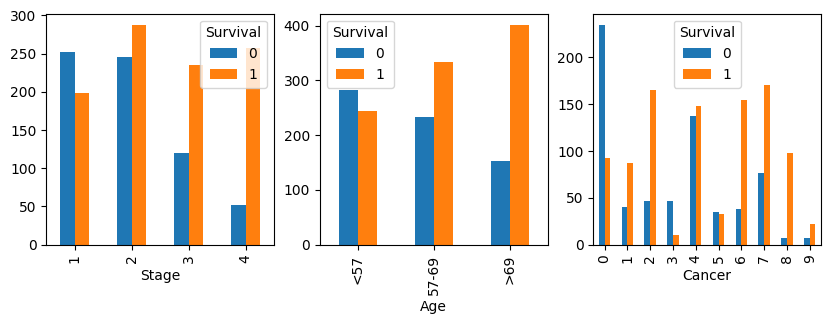

In [42]:
concepts = pcanc_train_cohort[['Cancer', 'Stage', 'Age', 'Survival']]
concepts.groupby(['Survival'])['Stage'].value_counts()

fig, axes = plt.subplots(1,3,figsize=(10,3))

stage_surv = concepts.groupby(['Stage', 'Survival']).size().unstack()
stage_surv.plot(kind='bar', stacked=False, ax=axes[0])

age_surv = concepts.groupby(['Age', 'Survival']).size().unstack()
age_surv.plot(kind='bar', stacked=False, ax=axes[1])

tis_surv = concepts.groupby(['Cancer', 'Survival']).size().unstack()
tis_surv.plot(kind='bar', stacked=False, ax=axes[2])

<Axes: xlabel='Cancer'>

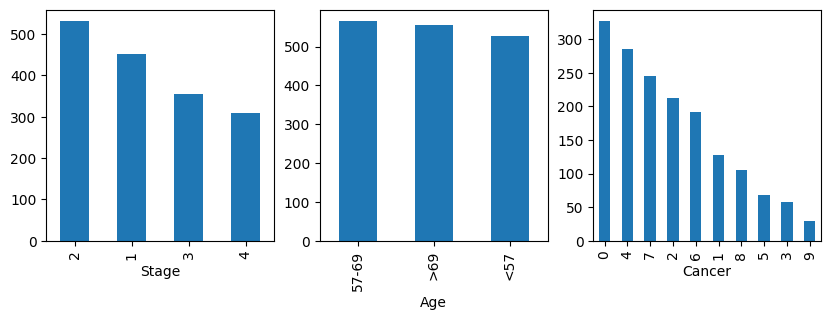

In [43]:
fig, axes = plt.subplots(1,3,figsize=(10,3))

stage_counts = pcanc_train_cohort['Stage'].value_counts()
stage_counts.plot(kind='bar', ax=axes[0])

stage_counts = pcanc_train_cohort['Age'].value_counts()
stage_counts.plot(kind='bar', ax=axes[1])

cancer_counts = pcanc_train_cohort['Cancer'].value_counts()
cancer_counts.plot(kind='bar', ax=axes[2])

In [44]:
pcanc_train_cohort = pcanc_train_cohort.drop(
    columns=[
        'project_id_x', 
        'case_id', 
        'case_submitter_id_x', 
        'days_to_death',
        'days_to_last_follow_up',
        'vital_status',
        '24_months', 
        '36_months', 
        '18_months',
        '120_months',
    ])

pcanc_train_cohort.head()

,Stage,Age,Cancer,Survival,ID
0,4,>69,9,1,TCGA-AG-3582
1,1,<57,0,0,TCGA-E2-A1IO
2,1,<57,3,0,TCGA-KM-A7QC
3,3,>69,0,0,TCGA-AC-A2BK
4,3,57-69,4,1,TCGA-B0-4813


In [12]:
pcanc_train_cohort.to_csv('/home/clinical-concepts/maracuja.clinical-concepts/data/stcanage_36surv_train.csv')

#### CENSORED

In [ ]:
survival = pd.read_csv('/home/clinical-concepts/maracuja.clinical-concepts/data/Survival_18_36_60_v2.csv')

In [ ]:
survival = survival[~((survival['vital_status']=='Dead')&(survival['days_to_death'].isna()))]
survival = survival[~((survival['vital_status']=='Alive')&(survival['days_to_last_follow_up'].isna()))]
print(len(survival))
survival = survival[~(survival['days_to_last_follow_up']<0)]
survival = survival[~(survival['days_to_death']<0)]
print(len(survival))

In [15]:
survival["time"] = survival.apply(lambda row: row["days_to_death"] if row["vital_status"] == "Dead" else row["days_to_last_follow_up"], axis=1)
survival["event"] = survival["vital_status"].apply(lambda x: 1 if x == "Dead" else 0)

In [ ]:
censored = survival[['case_submitter_id', 'time', 'event']]
censored = censored.rename(columns={'case_submitter_id': 'ID'})
censored.to_csv('/home/clinical-concepts/maracuja.clinical-concepts/data/censored.csv')

In [10]:
len(censored[censored['event']==1])/len(censored)

## Binary one-vs-rest Preprocessing

In [26]:
SURVIVAL_POINT = '60_months'

In [27]:
def binarize(concepts, columns):
    for c in columns:
        unique = list(concepts[c].unique())
        for v in unique:
            concepts[f"{c}_{v}"] = (concepts[c] == v).astype(int)
            
    return concepts

In [28]:
########## LOAD CONCEPTS DATA ##########

concepts = pd.read_csv('/SAN/colcc/Hormad1/data/clinical/concepts_v1_11_11_24.csv')
#concepts = pd.read_csv('/Users/k2030634/PhD/Isambard/data/concepts_v1_11_11_24.csv')
missing_values = concepts.isnull().sum()
missing_values  = (concepts.isnull().sum()/(len(concepts))*100)
concepts_exeth = concepts[['case_id', 'project_id', 'age_at_index', 'stage_var']]
concepts_exeth = concepts_exeth.dropna()
quantiles = concepts_exeth['age_at_index'].quantile([1/3, 2/3]).values

concepts_exeth['age_group'] = pd.cut(
    concepts_exeth['age_at_index'],
    bins=[-float('inf'), quantiles[0], quantiles[1], float('inf')],
    labels=[0, 1, 2]
)

concepts_exeth['stage_var'] = concepts_exeth['stage_var'].apply(lambda x: x-1)
concepts_exeth = concepts_exeth.drop(columns=['age_at_index'])

encoder = LabelEncoder()
concepts_exeth['stage_var'] = concepts_exeth['stage_var'].astype(int)
concepts_exeth['project_id'] = encoder.fit_transform(concepts_exeth['project_id'])

concepts_exeth = binarize(concepts_exeth, ['stage_var', 'age_group', 'project_id'])

In [29]:
########## LOAD SURVIVAL DATA ##########

survival = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/Survival_18_36_60_v2.csv')
#survival = pd.read_csv('/home/clinical-concepts/maracuja.clinical-concepts/data/survival_WSIs_v1.csv')
#survival = pd.read_csv('/Users/k2030634/PhD/Isambard/data/survival_WSIs_v1.csv')

survival = survival[survival[SURVIVAL_POINT]!='Censored']
survival = survival[survival[SURVIVAL_POINT]!='Unknown']
survival = survival[~survival[SURVIVAL_POINT].isna()]
survival['60_months'].value_counts()

60_months
Died     1034
Alive     795
Name: count, dtype: int64

In [30]:
########## LOAD CLINICAL DATA ##########

clinical = pd.read_csv('/SAN/colcc/Hormad1/data/clinical/WSI-pancancer-metadata/clinical.cart.2024-10-24/clinical.tsv', delimiter='\t')
#clinical = pd.read_csv('/Users/k2030634/PhD/Isambard/data/WSI-pancancer-metadata/clinical.cart.2024-10-24/clinical.tsv', delimiter='\t')
clinical = clinical[['case_id', 'case_submitter_id']]
clinical.head()

,case_id,case_submitter_id
0,000d566c-96c7-4f1c-b36e-fa2222467983,TCGA-KK-A7B2
1,000d566c-96c7-4f1c-b36e-fa2222467983,TCGA-KK-A7B2
2,0011a67b-1ba9-4a32-a6b8-7850759a38cf,TCGA-DC-6158
3,0011a67b-1ba9-4a32-a6b8-7850759a38cf,TCGA-DC-6158
4,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU


In [31]:
########## MERGE CONCEPTS, CLINICAL AND SURVIVAL DATA ##########

pcanc_train_cohort = pd.merge(concepts_exeth, survival, how='inner', left_on='case_id', right_on='case_id')
pcanc_train_cohort = pd.merge(pcanc_train_cohort, clinical, how='left', left_on='case_id', right_on='case_id')
#pcanc_train_cohort = pcanc_train_cohort[['case_submitter_id_y', 'project_id_y', 'stage_var', 'age_group', '18_months_Survival']]
#pcanc_train_cohort = pcanc_train_cohort.drop(columns=['case_id'])
pcanc_train_cohort = pcanc_train_cohort.rename(columns = {
    'case_submitter_id_y': 'ID', 
    'project_id_y': 'Cancer',
    'stage_var': 'Stage', 
    'age_group': 'Age',  
    '60_months': 'Survival'})

pcanc_train_cohort['Survival'] = encoder.fit_transform(pcanc_train_cohort['Survival'])
pcanc_train_cohort = pcanc_train_cohort.drop_duplicates()
#hn_train_cohort = pcanc_train_cohort[pcanc_train_cohort['Cancer']=='TCGA-HNSC']
pcanc_train_cohort = pcanc_train_cohort.sample(frac=1).reset_index(drop=True)

pcanc_train_cohort['Survival'].value_counts()

Survival
1    980
0    669
Name: count, dtype: int64

In [32]:
pcanc_train_cohort = pcanc_train_cohort.drop(
    columns=[
        'project_id_x', 
        'case_id', 
        'Cancer',
        'case_submitter_id_x', 
        'days_to_death',
        'days_to_last_follow_up',
        'vital_status',
        '24_months', 
        '36_months', 
        '18_months',
        '120_months',
    ])

pcanc_train_cohort.head()

,Stage,Age,stage_var_0,stage_var_1,stage_var_2,stage_var_3,age_group_2,age_group_1,age_group_0,project_id_9,...,project_id_4,project_id_7,project_id_6,project_id_1,project_id_2,project_id_8,project_id_3,project_id_5,Survival,ID
0,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,TCGA-B6-A0IA
1,2,1,0,0,1,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,TCGA-B0-4706
2,1,2,0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,TCGA-D6-6515
3,3,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,1,TCGA-G7-6789
4,3,1,0,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,1,TCGA-QK-A8Z8


In [33]:
bin_pcanc_train_cohort = pcanc_train_cohort

In [47]:
set(pcanc_train_cohort['ID']) - set(bin_pcanc_train_cohort['ID'])

set()

In [8]:
pcanc_train_cohort.to_csv('/SAN/colcc/Hormad1/data/datasets/bin_stcanage_60surv_train.csv')

In [8]:
pcanc_train_cohort.columns

Index(['case_id', 'project_id_x', 'Stage', 'Age', 'stage_var_0', 'stage_var_1',
       'stage_var_2', 'stage_var_3', 'age_group_2', 'age_group_1',
       'age_group_0', 'project_id_9', 'project_id_0', 'project_id_4',
       'project_id_7', 'project_id_6', 'project_id_1', 'project_id_2',
       'project_id_8', 'project_id_3', 'project_id_5', 'case_submitter_id_x',
       'Cancer', 'vital_status', 'days_to_death', 'days_to_last_follow_up',
       '18_months', '24_months', '36_months', 'Survival', '120_months', 'ID'],
      dtype='object')